# Vertical integration: RNA + ADT, every method

This notebook runs every method that has a variant for vertical RNA + ADT on `D11`: Concerto, MOFA2, Matilda, Multigrate, Seurat_WNN, UINMF, VIMCCA, moETM, scMDC, scMM, scMSI, scMoMaT, sciPENN and totalVI. The [tutorial](https://dsichang.github.io/scMultiBench/tutorials/vertical_rna_adt/) explains each step and runs Matilda and sciPENN only.

Methods run on Linux. The environments are 14 envs, 32.5 GB to download on a CPU host, 40.8 GB on a GPU host.

## 1. Install

This cell installs `multibench-sc`. It keeps the numpy and pandas that are already installed, so Colab needs no restart.

<details>
<summary>Details</summary>

On Colab, choose a GPU runtime before you run the notebook: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, an environment that has a smaller CPU build gets that build, and training methods run slower.

</details>

In [1]:
import numpy, pandas
%pip install -q multibench-sc numpy=={numpy.__version__} pandas=={pandas.__version__}

Note: you may need to restart the kernel to use updated packages.


## 2. Download the data and the environments

In [2]:
import pandas as pd
import multibench as mtb

mtb.data.fetch("D11")

PosixPath('/tmp/mbverify/home/.cache/multibench/data')

In [3]:
METHODS = ["Concerto", "MOFA2", "Matilda", "Multigrate", "Seurat_WNN", "UINMF",
           "VIMCCA", "moETM", "scMDC", "scMM", "scMSI", "scMoMaT", "sciPENN",
           "totalVI"]
envs = mtb.env.install(METHODS, dry_run=False)
pd.DataFrame(envs)[["env", "methods", "state"]]

,env,methods,state
0,MOFA2_env,[MOFA2],have
1,env_moETM,[moETM],have
2,env_sciPENN,[sciPENN],have
3,matilda,[Matilda],have
4,scmb_concerto,[Concerto],have
5,scmb_multigrate2,[Multigrate],have
6,scmb_r,[UINMF],have
7,scmb_scmdc,[scMDC],have
8,scmb_scmm2,[scMM],have
9,scmb_scmsi,[scMSI],have


## 3. Run the methods

Seurat_WNN returns a neighbour graph, not an embedding. The package scores embeddings, so its row has the status `RUN_OK_NO_EMBEDDING` and no scores, and the figure leaves it out.

In [4]:
res = mtb.run_all("D11", "vertical", methods=METHODS,
                  out_dir="out/D11_all")
res.summary

[run_all] 15 more rows need files this folder does not have. mtb.scan shows them.


[run_all] Concerto (vertical/D11) ...


[run_all]   -> CHAIN_OK (209.7s) ARI 0.357


[run_all] MOFA2 (vertical/D11) ...


[run_all]   -> CHAIN_OK (44.6s) ARI 0.474


...

[run_all] sciPENN (vertical/D11) ...


[run_all]   -> CHAIN_OK (8.9s) ARI 0.649


[run_all] totalVI (vertical/D11) ...


[run_all]   -> CHAIN_OK (59.2s) ARI 0.821


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,label_order_note,caveat,reason
0,Concerto,CHAIN_OK,209.7,embedding,"[2864, 128]",0,cty.csv,NaN,None,1,0.3572,0.4248,0.5057,0.5109,0.4856,0.8652,single ordering,,
1,MOFA2,CHAIN_OK,44.6,embedding,"[2864, 17]",0,cty.csv,NaN,None,1,0.4743,0.6747,0.4733,0.4671,0.6594,0.9311,single ordering,,
2,Matilda,CHAIN_OK,16.7,embedding,"[2864, 100]",10,cty.csv,NaN,None,1,0.9290,0.9258,0.6793,0.6822,0.9568,0.9989,single ordering,,
3,Multigrate,CHAIN_OK,42.5,embedding,"[2864, 15]",3,cty.csv,NaN,None,1,0.7193,0.7840,0.6609,0.6477,0.7542,0.9960,single ordering,,
4,Seurat_WNN,RUN_OK_NO_EMBEDDING,16.8,graph,None,0,None,NaN,None,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,not scored,,
5,UINMF,CHAIN_OK,18.5,embedding,"[2864, 30]",0,cty.csv,NaN,None,1,0.5059,0.6369,0.5541,0.5200,0.6007,0.9557,single ordering,,
6,VIMCCA,CHAIN_OK,17.1,embedding,"[2864, 8]",0,cty.csv,NaN,None,1,0.7609,0.7930,0.5926,0.5704,0.7637,0.9881,single ordering,,
7,moETM,CHAIN_OK,8.7,embedding,"[2864, 100]",0,cty.csv,NaN,None,1,0.6583,0.7278,0.5550,0.5697,0.6647,0.9627,single ordering,,
8,scMDC,CHAIN_OK,69.5,embedding,"[2864, 16]",24,cty.csv,NaN,None,1,0.6638,0.7135,0.6191,0.5868,0.6448,0.9794,single ordering,,
9,scMM,CHAIN_OK,32.1,embedding,"[2864, 10]",19,cty.csv,NaN,None,1,0.6913,0.7182,0.5721,0.5479,0.6683,0.9703,single ordering,,


## 4. Plot

`res.plot()` draws the scores as a bubble table. Circle size shows the rank within a column, and bigger is better. The fill compares a value with the other rows in the same column.

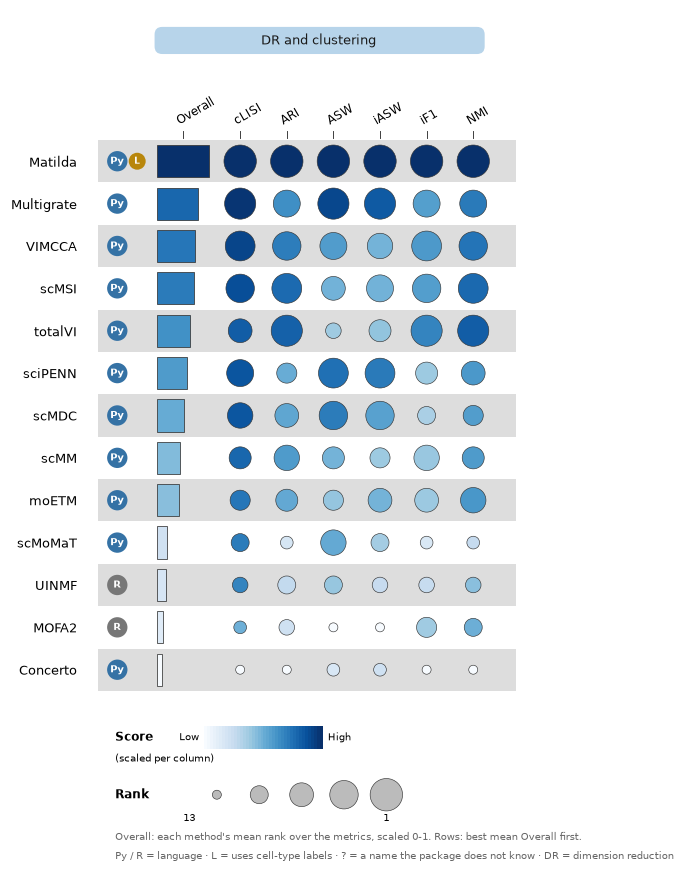

In [5]:
res.plot()